# 3D решение
Реализация рассеияния гауссова пакета на точечном потенциале Юкавы

## Импорты

In [2]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import pyvista as pv

## Уравнение пакета

Полное 3D уравнение Шрёдингера:
 $$i \frac{\partial \psi}{\partial t} = - \frac{1}{2} \left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2} + \frac{\partial^2}{\partial z^2} \right) \psi + V \left( \sqrt{x^2 +y^2 +z^2} \right) \psi$$

- Летит вдоль $x$
- Смещен на $b$ по $y$ (прицельный параметр)
- По $z$ - симметричный гауссиан с центром $z=0$

Импульс и дискретизация должны быть соотнесены следующим образом:
$$k_0 < k_{\text{max}}=\frac{\pi}{\Delta x}$$
иначе движение не будет промоделировано.

In [3]:
# Параметры системы
L = 100.0  # длина системы
N = 144  # дискретизация
T = 30  # общее время симуляции

# Сетка
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)

hbar = 1.0  # пост. Дирака
m = 1.0  # масса

# Дифференциалы
dx = L/N
dt = 0.01

# Волновой пакет
x0, k0, b = -35.0, 3.0, 5.0  # ширина, положение, импульс, прицельный
sigma_x, sigma_y, sigma_z = 3.0, 3.0, 1.0  # узкий по z

psi = np.exp(-((X - x0)**2 / (4*sigma_x**2) +
               (Y - b)**2 / (4*sigma_y**2) +
               Z**2 / (4*sigma_z**2))) * np.exp(1j * k0 * X)
psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx**3) # нормировка

## Потенциал и поглощающие границы

### Потенциал Юкавы

$$V_{\text{yk}}(r) = \frac{e^{-r/R}}{r + \varepsilon}$$

где:
- $R$ - характерный размер потенциала
- $\varepsilon = 0.5\,\Delta x$ (предотвращает сингулярность при $r \to 0$)

При $R \to \infty$ переходит в кулоновский $1/r$.

### Поглощающий слой

На границе введен потенциал $-iW(r)$:

$$W(r) = \begin{cases}
0, & r \leq R_{\max} - w, \\[4pt]
W_{0} \cdot \sin^2\left(\dfrac{\pi}{2} \cdot \dfrac{r - (R_{\max} - w)}{w}\right), & r > R_{\max} - w,
\end{cases}$$

где:
- $R_{\max} = L/2$ - граница области
- $w$ - ширина слоя
- $W_{0}$ - интенсивность

$\sin^2$ выбран для гладкости второй производной (минимизация отражения), мнимость для экспоненциального затухания.

### Итоговый потенциал

$$V(r) = V_{\text{yk}}(r) - i\,W(r)$$

P.S. Поглощающий слой вводим для иммитации открытой системы.

In [4]:
# Потенциал Юкавы
R_param = 20.0
eps = 0.5 * dx
V_yk = 5.0*np.exp(-R/R_param)/(R+eps)

# Поглощающий слой
W_max = 2.0
width = 15.0
R_max = L/2
W = np.zeros_like(R)
mask = R > R_max - width
W[mask] = W_max * np.sin(np.pi/2 * (R[mask] - (R_max - width))/width)**2

# Итоговый потенциал
V = V_yk - 1j * W

## Метод Split-Operator

Сначала укажем, что метод Кранка - Николсон для трех измерений будет слишком затратным, т.к. матрицу не удается привести к трехдиагональной (см. ниже). Потому воспользуемся другим.

Суть метода Split-Operator заключается в разложении экспоненты от некоммутирующих операторов в ряд Тейлора.
### Исходное уравнение
$$i \frac{\partial \psi}{\partial t} = \hat{H} \psi = (\hat{T}+\hat{V})\psi$$
где:
- $\hat{T}=-\frac{1}{2} \nabla^2$ - оператор кинетической энергии,
- $\hat{V}=V(r)$ - оператор потенциала.

Тогда формальное решение задачи имеет вид:
$$\psi = e^{-i \hat{H} t} \psi_0 \quad \Leftrightarrow \quad  \psi(t+\Delta t) = e^{-i \hat{H} \Delta t} \psi(t)$$

Представляя подставляя операторы имеем:
$$e^{-i \hat{H} \Delta t} = e^{-i \hat{V} \Delta t/2} \cdot e^{-i \hat{T} \Delta t} \cdot e^{-i \hat{V} \Delta t/2}=e^A \cdot e^B \cdot e^A$$

### Формула Бейкера-Кэмпбелла-Хаусдорфа
$$e^{X} e^{Y} = e^{Z}$$
$$Z=X+Y+\frac{1}{2}\left[X,Y\right] + \frac{1}{12}\left[X,\left[X,Y\right]\right] + \frac{1}{12}\left[Y,\left[Y,X\right]\right]+\mathcal{O}(\Delta t^4)$$

Применительно к нашему уравнению, раскладывая до 2-го порядка включительно:
$$e^{B} e^{A} = e^{C_1}, \quad e^{A} e^{C_1} = e^{C_2}$$
$$C_1 = B+A+\frac{1}{2}\left[B,A\right]$$
$$C_2 = A+C_1+\frac{1}{2}\left[A,C_1\right]$$

Сразу группируя порядки:
$$С_2 = (2A+B) + \left(\frac{1}{2} \left[ B,A \right] + \frac{1}{2} \left[ A,B+A \right]\right) = 2A+B$$

Итоговое уравнение принимает вид:
$$\psi(t+\Delta t) = e^{-i \hat{V} \Delta t/2}e^{-i \hat{T} \Delta t}e^{-i \hat{V} \Delta t/2} \psi(t) + \mathcal{O}(\Delta t^3)$$

Общая ошибка симуляции:
$$\sim \frac{T}{\Delta t} \Delta t^3 = T \Delta t^2$$

## Сравнение сложности алгоритмов

### Схема Кранка-Николсона
$3D$ cетка $N^3$ точек. Каждая граничит с 6-ю. В матрице хранятся как $(i$, $j N$, $k N^2)$. Дальний сосед (по $z$) остоит на $b=\pm N^2$. Матрица гамильтониана имеет размер $M \times M$, где $M=N^3$.

LU-разложение обеспечивающее решение системы выполняется за сложность $M \cdot \frac{b}{2} \cdot \frac{b}{2} \sim \mathcal{O}(N^7)$

### Схема Split-operator
- Потенциал решается за линейную сложность от всех точек, подстановкой $\sim \mathcal{O}(N^3)$.
- Кинетическая энергия в импульсном представлении представляет из себя диагональный оператор $\hat{T} \to k^2/2$, а потому СЛАУ может быть решена с помощью быстрых преобразований фурье $\sim \mathcal{O}(N^3 \log{N})$


In [5]:
# Сетка частот
kx = 2 * np.pi * np.fft.fftfreq(N, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(N, d=dx)
kz = 2 * np.pi * np.fft.fftfreq(N, d=dx)
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
K02 = KX**2 + KY**2 + KZ**2

# Экспоненты
exp_V_half = np.exp(-0.5j * V * dt)
exp_T = np.exp(-0.5j * K02 * dt)

## Раскадровка и проверка нормы

Произведем рассчет ошибки моделирования по величине нормы. Т.к. на границах поглощающий слой, норма системы убвает. Учтем это с помощью уравнения непрерывности для нашего уравнения Шрёдингера $i \psi_t = \hat{H}\psi + V\psi - i W \psi$. Изменение плотности вероятности:

$$\frac{\partial |\psi|^2}{\partial t} + \nabla \cdot \mathbf{J} = -2 W |\psi|^2$$

где $\mathbf{J}= \text{Im} (\psi^* \nabla \psi)$ - плотность потока вероятности (унитарная вещественная часть норму не меняет).

Интегрируя по области:

$$\int_G \frac{\partial|\psi|^2}{\partial t} d^3r + \int_G \nabla\cdot\mathbf{J}\, d^3r = -2\int_G W|\psi|^2 d^3r$$
$$\frac{d}{d t} \|\psi\|^2 + \oint_{\partial G} \mathbf{J}\cdot d\mathbf{S} = - 2\int_G W|\psi|^2 d^3r$$

Считаем что поток через границу области нулевой. Второе слагаемое уходит:

$$\frac{d}{d t} \|\psi\|^2 = - 2\int_G W|\psi|^2 d^3r$$

Тогда через время $T$ должно выполняться:

$$\|\psi(0)\|^2=\|\psi(T)\|^2 + 2\int_T\int_G W|\psi|^2 d^3r$$

По теореме о среднем на каждом шаге:
$$\Delta A = 2 \Delta t \sum W|\psi|^2 \Delta x \Delta y \Delta z$$
$$A=\sum \Delta A$$

Относительная ошибка моделирования:
$$\varepsilon = \frac{\bigl| \|\psi(T)\|^2 + A - \|\psi(0)\|^2 \bigr|}{\|\psi(0)\|^2}$$

Напомним, что ожидаемая ошибка составляет $\sim T\Delta t^2$.

In [6]:
steps = int(T / dt)
save_every = max(1,steps // 200)

# Норма
norm_init = np.sum(np.abs(psi)**2) * dx**3
absorb = 0.0

In [7]:
frames = []

for n in range(steps):
    psi *= exp_V_half
    psi = np.fft.fftn(psi)
    psi *= exp_T
    psi = np.fft.ifftn(psi)
    psi *= exp_V_half

    # Норма
    psi2 = np.abs(psi)**2
    absorb += 2 * np.sum(W * psi2) * dx**3 * dt

    if n % save_every == 0:
        frames.append(np.abs(psi)**2)

norm_last = np.sum(np.abs(psi)**2) * dx**3
norm_all = norm_last + absorb
err_sum = abs(norm_all - norm_init) / norm_init

print(f"До:     {norm_init:.6f}")
print(f"После:  {norm_last:.6f}")
print(f"Ушло:   {absorb:.6f}")
print(f"Итого:  {norm_all:.6f}")
print(f"Ошибка: {err_sum:.2e}")

До:     1.000000
После:  0.004632
Ушло:   0.994240
Итого:  0.998872
Ошибка: 1.13e-03


In [11]:
print(f"Ожидаемая ошибка нормы: {dt**2*T:.2e}")

Ожидаемая ошибка нормы: 3.00e-03


## Анимация в проекциях

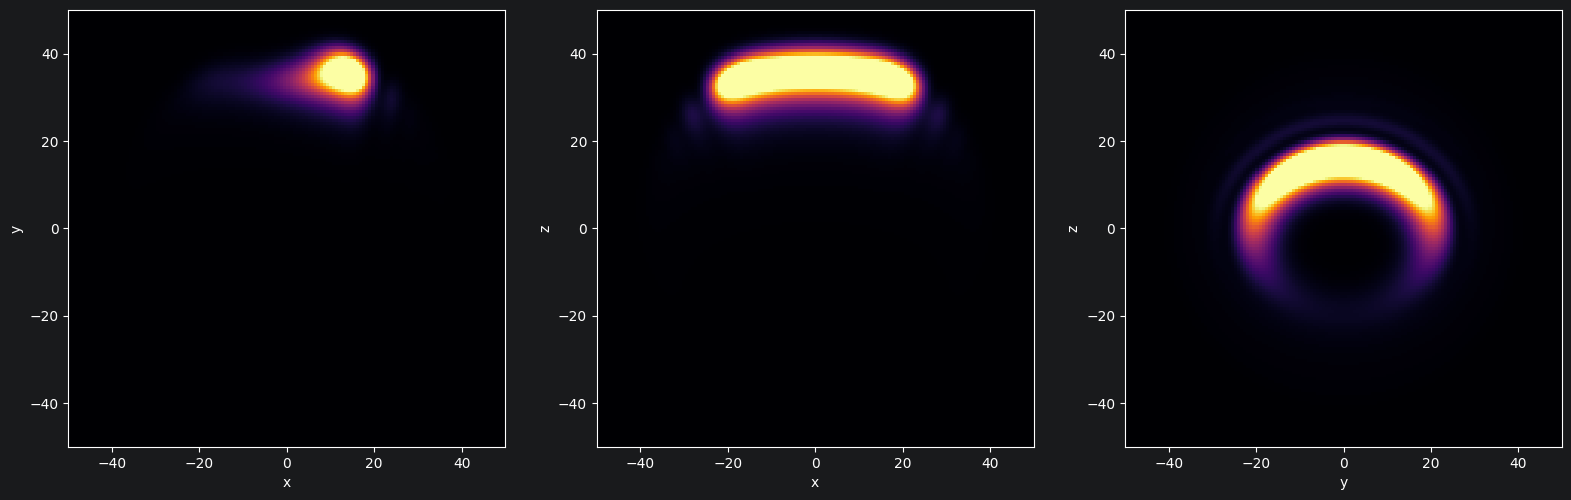

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

frames_xy = [np.sum(f, axis=2) for f in frames]
frames_xz = [np.sum(f, axis=1) for f in frames]
frames_yz = [np.sum(f, axis=0) for f in frames]

xy = axes[0].imshow(frames_xy[0], extent=[-L / 2, L / 2, -L / 2, L / 2], origin='lower', cmap='inferno')
xz = axes[1].imshow(frames_xz[0], extent=[-L / 2, L / 2, -L / 2, L / 2], origin='lower', cmap='inferno')
yz = axes[2].imshow(frames_yz[0], extent=[-L / 2, L / 2, -L / 2, L / 2], origin='lower', cmap='inferno')

axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[1].set_xlabel('x')
axes[1].set_ylabel('z')
axes[2].set_xlabel('y')
axes[2].set_ylabel('z')

plt.tight_layout()

txt = fig.text(0.98, 0.02, '', fontsize=12, ha='right', va='bottom', transform=fig.transFigure)

def update(i):
    xy.set_array(frames_xy[i])
    xz.set_array(frames_xz[i])
    yz.set_array(frames_yz[i])

    xy.set_clim(vmin=0, vmax=frames_xy[i].max() * 0.5)
    xz.set_clim(vmin=0, vmax=frames_xz[i].max() * 0.5)
    yz.set_clim(vmin=0, vmax=frames_yz[i].max() * 0.5)

    txt.set_text(i)
    return [xy, xz, yz, txt]


ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=60, blit=True)
ani.save('sc_3d_plane.gif', writer='pillow', fps=20)

## Анимация срезов
В плоскости $xy$
1. Срез вдоль: $(y=0, z=0)$
2. Срез поперек: $(x=0, z=0)$

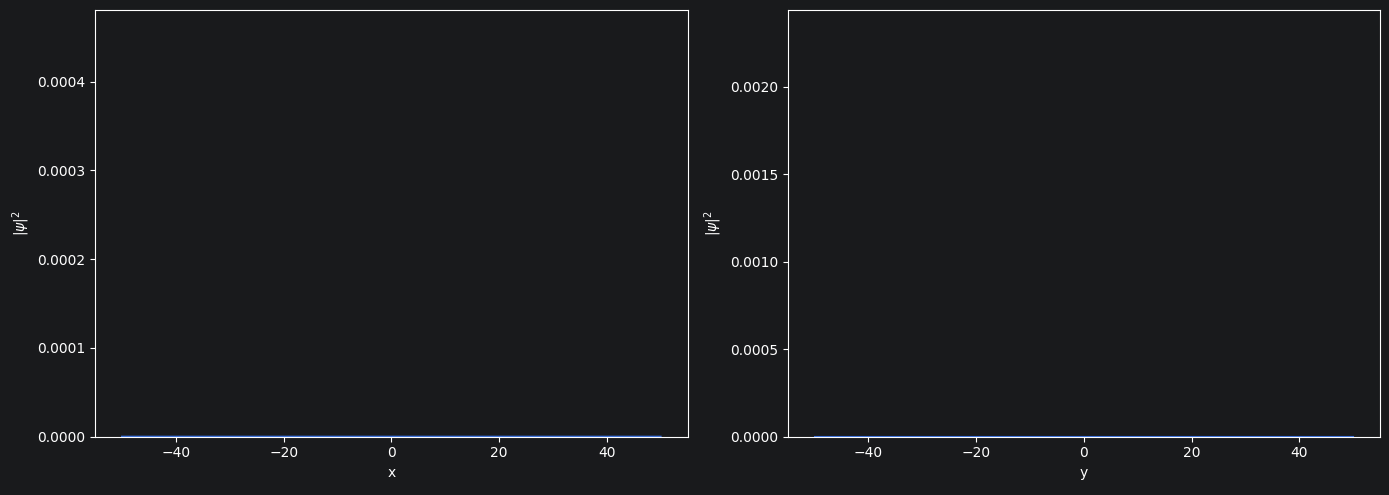

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

zero = N // 2

line_x = np.array([f[zero, zero, :] for f in frames])
line_y = np.array([f[:, zero, zero] for f in frames])

line1, = ax1.plot(x, line_x[0])
ax1.set_ylim(0, line_x.max() * 1.2)
ax1.set_xlabel('x')
ax1.set_ylabel(r'$|\psi|^2$')

line2, = ax2.plot(y, line_y[0])
ax2.set_ylim(0, line_y.max() * 1.2)
ax2.set_xlabel('y')
ax2.set_ylabel(r'$|\psi|^2$')

plt.tight_layout()

txt = fig.text(0.98, 0.02, '', fontsize=12, ha='right', va='bottom', transform=fig.transFigure)

def update(i):
    line1.set_ydata(line_x[i])
    line2.set_ydata(line_y[i])
    txt.set_text(i)
    return [line1, line2, txt]

ani = animation.FuncAnimation(fig, update, frames=len(line_x), interval=50, blit=True)
ani.save('sc_1d.gif', writer='pillow', fps=20)

## 3D-рендеринг

In [45]:
plot = pv.Plotter(off_screen=True, window_size=(800, 600))
plot.open_gif('sc_3d_volume.gif')
plot.camera_position = [(-L, L, L/2), (0, 0, 0), (0, 0, 1)]

for frame in frames[::5]:
    g = pv.ImageData()
    g.dimensions = (N, N, N)
    g.spacing = (dx, dx, dx)
    g.origin = (-L/2, -L/2, -L/2)
    g.point_data['|ψ|²'] = frame.flatten(order='F')

    plot.clear()
    plot.add_volume(g, scalars='|ψ|²', cmap='inferno',
                    opacity='sigmoid', clim=[0, vmax])
    plot.write_frame()

plot.close()

## Вывод

1. __Метод.__ Реализована схема Split-Operator для нестационарного уравнения Шрёдингера в 3D на сетке $N = 144$,
   $L = 100$. Граничные условия $-iW(r)$, для иммитации открытой системы.

2. __Рассеяние.__ Волновой пакет ($k_0 = 3$, $\sigma_{x,y}=3$, $\sigma_z=1$,
   $b = 5$) рассеивается на потенциале Юкавы $V(r) = 5e^{-r/20}/r$.
   Пакет подходит к центру, облетает потенциал с прицельным параметром. Формируется расходящаяся волна.

3. __Анимация.__ Построено три проекции (XY, XZ, YZ),
   1D срезы вдоль осей XY, а так же 3D объемный вид.

4. __Сохранение нормы.__ Выполнен рассчет нормы с поглотителем.
   Относительная ошибка составила $\varepsilon \approx 1.1\cdot 10^{-3}$, что согласуется с ожидаемой $T \cdot \Delta t^2 \sim 3.0 \cdot 10^{-3}$ при $T=30$.

5. __Итог.__ Расхождений с теорией не наблюдается.
